# Machine Translation Tutorial: English to Spanish

This notebook demonstrates fine-tuning a pre-trained translation model using Hugging Face Transformers.

**What we'll cover:**
- Loading translation datasets
- Tokenization for seq2seq models
- Data collators and batch processing
- Training and evaluation
- Creating translation pipelines

# 1. Load Dataset

We'll use the KDE4 dataset containing English-Spanish translation pairs. For this tutorial, we'll work with a subset to speed up training.

In [111]:
from datasets import load_dataset

data=load_dataset("kde4",lang1="en",lang2="es",trust_remote_code=True)

In [112]:
data=data["train"].shuffle(seed=42).select(range(1000))
data

Dataset({
    features: ['id', 'translation'],
    num_rows: 1000
})

In [113]:
data=data.train_test_split(test_size=0.1)

In [114]:
data

DatasetDict({
    train: Dataset({
        features: ['id', 'translation'],
        num_rows: 900
    })
    test: Dataset({
        features: ['id', 'translation'],
        num_rows: 100
    })
})

# 2. Load Tokenizer

## Why Use Helsinki-NLP/opus-mt-en-es Tokenizer?

The tokenizer is crucial for machine translation because it determines how text is converted to numbers that the model understands. Here's why we use this specific tokenizer:

### 1. **Language-Pair Specific Training**
- This tokenizer was trained specifically on English-Spanish translation pairs
- It understands the vocabulary and patterns of both languages
- It knows common subwords that appear in English→Spanish translations

### 2. **Subword Tokenization Benefits**
- Handles **out-of-vocabulary words** by breaking them into known subword pieces
- **Example**: "unbelievable" → ["un", "believ", "able"] 
- Works well for **morphologically rich languages** like Spanish with many verb conjugations

### 3. **Model Compatibility**
- The tokenizer vocabulary **must match** the model's vocabulary exactly
- Using a different tokenizer would cause vocabulary mismatches
- The model expects specific token IDs that this tokenizer produces

### 4. **Special Tokens for Translation**
- Includes special tokens needed for sequence-to-sequence models:
  - `<pad>`: For padding shorter sequences
  - `</s>`: End of sequence marker  
  - Language-specific tokens for multilingual scenarios

The tokenizer converts text into tokens that the model can understand. We'll use the Helsinki-NLP tokenizer designed for English-Spanish translation.

In [115]:
from transformers import AutoTokenizer

tokenizer=AutoTokenizer.from_pretrained("Helsinki-NLP/opus-mt-en-es")

C:\Users\Lenovo\AppData\Roaming\Python\Python311\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [116]:
sample_en=data["train"][10]["translation"]["en"]
sample_es=data["train"][10]["translation"]["es"]
sample_en, sample_es

('British English', 'Inglés británicoName')

# 3. Test Tokenization

Let's examine how the tokenizer processes English and Spanish text to understand the tokenization process.

In [117]:
input_tokens=tokenizer(sample_en)
input_tokens

{'input_ids': [5343, 1176, 0], 'attention_mask': [1, 1, 1]}

In [118]:
target_tokens=tokenizer(text_target=sample_es)
target_tokens

{'input_ids': [8917, 15537, 22882, 0], 'attention_mask': [1, 1, 1, 1]}

In [119]:
tokenizer.convert_ids_to_tokens(input_tokens["input_ids"])

['▁British', '▁English', '</s>']

In [120]:
tokenizer.convert_ids_to_tokens(target_tokens["input_ids"])

['▁Inglés', '▁británico', 'Name', '</s>']

# Understanding Data Collator with Examples

## What Does the Data Collator Do?

The `DataCollatorForSeq2Seq` performs several crucial tasks when preparing batches for training:

### 1. **Dynamic Padding**
- Pads sequences in each batch to the same length
- Uses the tokenizer's `pad_token_id` for padding
- Only pads to the longest sequence in the current batch (not global max)

### 2. **Creates Decoder Input IDs** 
- Automatically generates `decoder_input_ids` by shifting the labels
- This enables **teacher forcing** during training
- The model sees the correct previous token when predicting the next one

### 3. **Handles Special Tokens**
- Properly manages start tokens, end tokens, and padding
- Ensures the model knows where sequences begin and end

## Example from Our Notebook

When we run this code in our notebook:
```python
res = [tokenized_dataset["train"][i] for i in range(1,5)]
batch = data_collator(res)
```

**Input**: 4 tokenized examples with different lengths
**Output**: A properly formatted batch with:
- `input_ids`: English sentences (padded to same length)
- `attention_mask`: Indicates real vs padded tokens  
- `decoder_input_ids`: Shifted Spanish sequences for teacher forcing
- `labels`: Original Spanish sequences (what model should output)

The key insight: `decoder_input_ids` and `labels` are offset by one token, allowing the model to learn to predict the next Spanish word given the previous Spanish words.

# 4. Prepare Dataset for Training

We need to tokenize the entire dataset and set appropriate maximum lengths based on the data distribution.

### check the maximum length of the dataset for max limit restrictions

Text(0.5, 0, 'Input Length')

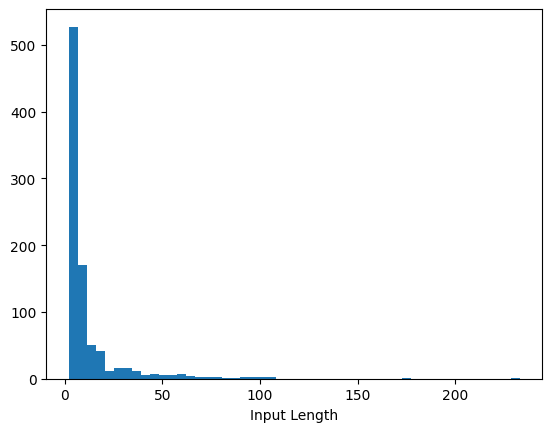

In [122]:
import matplotlib.pyplot as plt

train=data["train"]["translation"]
input_lens=[len(tokenizer(data["en"])["input_ids"]) for data in train]
plt.hist(input_lens, bins=50) # so all the length is around 120 we can choose 128 as max length
plt.xlabel("Input Length")

Text(0.5, 0, 'Input Length')

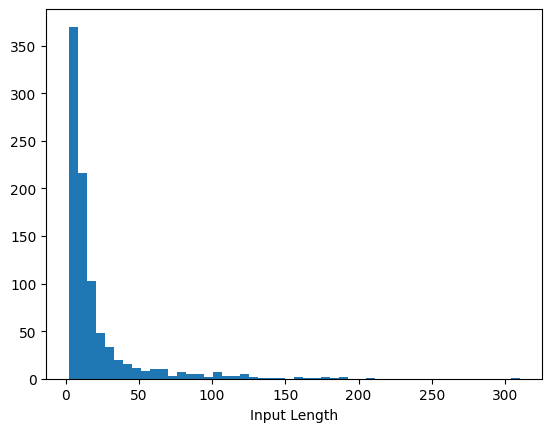

In [124]:
import matplotlib.pyplot as plt

train=data["train"]["translation"]
input_lens=[len(tokenizer(data["es"])["input_ids"]) for data in train]
plt.hist(input_lens, bins=50) # so all the length is around 120 we can choose 128 as max length
plt.xlabel("Input Length")

In [ ]:
max_input_length = 128
max_output_length = 200

def tokenization_function(data):
    inputs = [x["en"] for x in data["translation"]]
    targets = [x["es"] for x in data["translation"]]

    tokenized_inputs = tokenizer(inputs, truncation=True, max_length=max_input_length)
    tokenized_outputs = tokenizer(text_target=targets, truncation=True, max_length=max_output_length)

    tokenized_inputs["labels"] = tokenized_outputs["input_ids"]
    return tokenized_inputs

In [126]:
tokenized_dataset=data.map(tokenization_function, batched=True, remove_columns=data["train"].column_names)

Map:   0%|          | 0/900 [00:00<?, ? examples/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

In [127]:
tokenized_dataset

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 900
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 100
    })
})

In [128]:
from transformers import AutoModelForSeq2SeqLM

model=AutoModelForSeq2SeqLM.from_pretrained("Helsinki-NLP/opus-mt-en-es")

# 5. Load Pre-trained Model

We'll load the Helsinki-NLP sequence-to-sequence model that's already trained for English-Spanish translation.

In [129]:
from transformers import DataCollatorForSeq2Seq

data_collator=DataCollatorForSeq2Seq(tokenizer, model=model)

# 6. Data Collator in Action

The data collator handles batch processing, padding, and creates proper input formats for sequence-to-sequence training.

## Let's See What It Actually Does

In the cells below, we'll examine how the data collator transforms our tokenized data:

1. **Before**: Individual tokenized examples with different lengths
2. **After**: Properly batched and padded data ready for the model

Pay attention to how `decoder_input_ids` and `labels` are related - this is the key to understanding teacher forcing in sequence-to-sequence models.

In [133]:
res=[tokenized_dataset["train"][i] for i in range(1,5)]
res

[{'input_ids': [47323,
   34,
   42,
   4477,
   23902,
   2959,
   31,
   18268,
   6035,
   494,
   121,
   5,
   14743,
   82,
   211,
   895,
   412,
   6035,
   494,
   7,
   1562,
   3,
   5827,
   141,
   9607,
   21,
   0],
  'attention_mask': [1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1],
  'labels': [49962,
   34,
   54,
   3603,
   16426,
   19,
   1574,
   43,
   18268,
   6035,
   494,
   166,
   6,
   17205,
   236,
   629,
   895,
   412,
   6035,
   494,
   4,
   1602,
   3,
   50,
   2407,
   75,
   15744,
   30177,
   4,
   388,
   4,
   154,
   8612,
   21,
   0]},
 {'input_ids': [1072, 28193, 0],
  'attention_mask': [1, 1, 1],
  'labels': [5,
   3,
   5815,
   3,
   25,
   3960,
   8182,
   6074,
   2307,
   359,
   2908,
   3,
   3941,
   0]},
 {'input_ids': [568, 346, 356, 2229, 2317, 93, 0],
  'attention_mask': [1, 1, 1, 1, 1, 1, 1],
  'labels': [568,

In [134]:
batch=data_collator(res)
batch.keys()

dict_keys(['input_ids', 'attention_mask', 'labels', 'decoder_input_ids'])

In [135]:
batch["decoder_input_ids"]

tensor([[65000, 49962,    34,    54,  3603, 16426,    19,  1574,    43, 18268,
          6035,   494,   166,     6, 17205,   236,   629,   895,   412,  6035,
           494,     4,  1602,     3,    50,  2407,    75, 15744, 30177,     4,
           388,     4,   154,  8612,    21],
        [65000,     5,     3,  5815,     3,    25,  3960,  8182,  6074,  2307,
           359,  2908,     3,  3941,     0, 65000, 65000, 65000, 65000, 65000,
         65000, 65000, 65000, 65000, 65000, 65000, 65000, 65000, 65000, 65000,
         65000, 65000, 65000, 65000, 65000],
        [65000,   568,   346,   356,  2229,   110,  2223, 27011,  2221,  1200,
         22882,     0, 65000, 65000, 65000, 65000, 65000, 65000, 65000, 65000,
         65000, 65000, 65000, 65000, 65000, 65000, 65000, 65000, 65000, 65000,
         65000, 65000, 65000, 65000, 65000],
        [65000,    54,  5984,     4,    25,  1696, 25701,   359,    51,     0,
         65000, 65000, 65000, 65000, 65000, 65000, 65000, 65000, 65000, 650

In [136]:
tokenizer.convert_ids_to_tokens(batch["decoder_input_ids"][0])

['<pad>',
 '▁ADVERTENCIA',
 ':',
 '▁El',
 '▁tamaño',
 '▁estimado',
 '▁del',
 '▁archivo',
 '▁es',
 '▁%1',
 '▁Ki',
 'B',
 '▁pero',
 '▁la',
 '▁cinta',
 '▁tiene',
 '▁solo',
 '▁%',
 '2',
 '▁Ki',
 'B',
 '▁de',
 '▁espacio',
 '.',
 '▁¿',
 'Re',
 'a',
 'lizar',
 '▁Copia',
 '▁de',
 '▁seguridad',
 '▁de',
 '▁todos',
 '▁modos',
 '?']

### Decoder Input IDs Explained

The tokens above show what the **decoder sees as input** during training. Notice:
- It starts with a special token (usually `</s>` used as start token in this model)
- It contains the Spanish words but **shifted by one position**
- This allows the model to predict the next Spanish word at each step

In [137]:
batch["labels"]

tensor([[49962,    34,    54,  3603, 16426,    19,  1574,    43, 18268,  6035,
           494,   166,     6, 17205,   236,   629,   895,   412,  6035,   494,
             4,  1602,     3,    50,  2407,    75, 15744, 30177,     4,   388,
             4,   154,  8612,    21,     0],
        [    5,     3,  5815,     3,    25,  3960,  8182,  6074,  2307,   359,
          2908,     3,  3941,     0,  -100,  -100,  -100,  -100,  -100,  -100,
          -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,
          -100,  -100,  -100,  -100,  -100],
        [  568,   346,   356,  2229,   110,  2223, 27011,  2221,  1200, 22882,
             0,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,
          -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,
          -100,  -100,  -100,  -100,  -100],
        [   54,  5984,     4,    25,  1696, 25701,   359,    51,     0,  -100,
          -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -1

In [138]:
tokenizer.convert_ids_to_tokens(batch["labels"][0])

['▁ADVERTENCIA',
 ':',
 '▁El',
 '▁tamaño',
 '▁estimado',
 '▁del',
 '▁archivo',
 '▁es',
 '▁%1',
 '▁Ki',
 'B',
 '▁pero',
 '▁la',
 '▁cinta',
 '▁tiene',
 '▁solo',
 '▁%',
 '2',
 '▁Ki',
 'B',
 '▁de',
 '▁espacio',
 '.',
 '▁¿',
 'Re',
 'a',
 'lizar',
 '▁Copia',
 '▁de',
 '▁seguridad',
 '▁de',
 '▁todos',
 '▁modos',
 '?',
 '</s>']

### Labels Explained  

The tokens above show what the **model should output** (the target). Compare with decoder_input_ids:
- **Decoder Input**: `[</s>, "Como", "se", ...]` (what model sees)
- **Labels**: `["Como", "se", "llamam", ...]` (what model should predict)

This offset relationship enables **teacher forcing**: the model learns to predict each Spanish word by seeing the correct previous Spanish word, rather than its own potentially incorrect prediction.

In [139]:
!pip install sacrebleu bert-score

# 7. Evaluation Metrics

We'll use BLEU score and BERTScore to evaluate translation quality. BLEU measures n-gram overlap, while BERTScore uses contextual embeddings.

In [140]:
from evaluate import load
sacrebleu=load("sacrebleu")
bertscore=load("bertscore")


In [141]:
sacrebleu.compute(predictions=["small data"],references=[["small data"]])

{'score': 0.0,
 'counts': [2, 1, 0, 0],
 'totals': [2, 1, 0, 0],
 'precisions': [100.0, 100.0, 0.0, 0.0],
 'bp': 1.0,
 'sys_len': 2,
 'ref_len': 2}

In [142]:
sacrebleu.compute(predictions=["this is a very big line for sacreblue to work properly"],references=[["this is a really big line for sacreblue to work properly"]])

{'score': 70.16879391277372,
 'counts': [10, 8, 6, 4],
 'totals': [11, 10, 9, 8],
 'precisions': [90.9090909090909, 80.0, 66.66666666666667, 50.0],
 'bp': 1.0,
 'sys_len': 11,
 'ref_len': 11}

In [143]:
bertscore.compute(predictions=["this is a very big line for bertscore to work properly"], references=["this is a really big line for bertscore to work properly"], lang="en")

C:\Users\Lenovo\AppData\Roaming\Python\Python311\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


{'precision': [0.9931561946868896],
 'recall': [0.9931561946868896],
 'f1': [0.9931561946868896],
 'hashcode': 'roberta-large_L17_no-idf_version=0.3.12(hug_trans=4.44.2)'}

In [ ]:
import numpy as np

def compute_metrics(eval_pred):
    preds, labels = eval_pred

    decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    decoded_preds = [pred.strip() for pred in decoded_preds]
    decoded_labels = [label.strip() for label in decoded_labels]

    sacrebleu_result = sacrebleu.compute(predictions=decoded_preds, references=decoded_labels)
    bertscore_result = bertscore.compute(predictions=decoded_preds, references=decoded_labels, lang="es")

    return {
        "bleu": sacrebleu_result["score"],
        "bertscore_precision": np.mean(bertscore_result["precision"]),
        "bertscore_recall": np.mean(bertscore_result["recall"]),
    }

## Understanding the Compute Metrics Function

This function evaluates the quality of our translations during training. Here's what each step does:

### 1. **Input Processing**
- `preds`: Raw model predictions (token IDs)
- `labels`: Ground truth translations (token IDs)

### 2. **Decoding Predictions**
- `tokenizer.batch_decode()`: Converts token IDs back to readable Spanish text
- `skip_special_tokens=True`: Removes padding, start/end tokens

### 3. **Handling Label Preprocessing**
- `labels != -100`: Filters out ignored tokens (padding positions)
- `-100` is used to ignore certain positions during loss calculation
- Replaces `-100` with `pad_token_id` for proper decoding

### 4. **Text Cleaning**
- `.strip()`: Removes extra whitespace for fair comparison

### 5. **Metric Calculation**
- **BLEU Score**: Measures n-gram overlap between prediction and reference
- **BERTScore**: Uses contextual embeddings to measure semantic similarity
- **Language Setting**: `lang="es"` tells BERTScore we're evaluating Spanish

### 6. **Return Values**
- BLEU score (0-100, higher is better)
- BERTScore precision and recall (0-1, higher is better)

In [ ]:
from transformers import Seq2SeqTrainingArguments, Seq2SeqTrainer

training_args = Seq2SeqTrainingArguments(
    output_dir="opus_mt_en_es",
    eval_strategy="no",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    weight_decay=0.01,
    save_total_limit=3,
    num_train_epochs=3,
    predict_with_generate=True,
    fp16=True,
)

# 8. Training Configuration

Set up the training arguments and trainer for fine-tuning our translation model.

In [ ]:
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["test"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

In [147]:
trainer.evaluate(max_length=max_output_length)

c:\Users\Lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


  0%|          | 0/7 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

c:\Users\Lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\huggingface_hub\file_download.py:144: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Lenovo\.cache\huggingface\hub\models--bert-base-multilingual-cased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

C:\Users\Lenovo\AppData\Roaming\Python\Python311\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

{'eval_loss': 1.1699730157852173,
 'eval_model_preparation_time': 0.002,
 'eval_bleu': 44.72657200158071,
 'eval_bertscore_precision': 0.9158058643341065,
 'eval_bertscore_recall': 0.9031947869062423,
 'eval_runtime': 148.3651,
 'eval_samples_per_second': 0.674,
 'eval_steps_per_second': 0.047}

# 9. Evaluation and Training

First evaluate the pre-trained model, then fine-tune it and compare the results.

In [148]:
trainer.train()

  0%|          | 0/171 [00:00<?, ?it/s]

c:\Users\Lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'max_length': 512, 'num_beams': 4, 'bad_words_ids': [[65000]], 'forced_eos_token_id': 0}


{'train_runtime': 799.0663, 'train_samples_per_second': 3.379, 'train_steps_per_second': 0.214, 'train_loss': 1.0981675532826207, 'epoch': 3.0}


TrainOutput(global_step=171, training_loss=1.0981675532826207, metrics={'train_runtime': 799.0663, 'train_samples_per_second': 3.379, 'train_steps_per_second': 0.214, 'total_flos': 41403674787840.0, 'train_loss': 1.0981675532826207, 'epoch': 3.0})

In [149]:
trainer.evaluate(max_length=max_output_length)

c:\Users\Lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


  0%|          | 0/7 [00:00<?, ?it/s]

{'eval_loss': 1.0210976600646973,
 'eval_model_preparation_time': 0.002,
 'eval_bleu': 44.740175126789765,
 'eval_bertscore_precision': 0.9213369786739349,
 'eval_bertscore_recall': 0.9081987446546554,
 'eval_runtime': 74.3474,
 'eval_samples_per_second': 1.345,
 'eval_steps_per_second': 0.094,
 'epoch': 3.0}

In [151]:
trainer.save_model("opus_mt_en_es_final")

Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'max_length': 512, 'num_beams': 4, 'bad_words_ids': [[65000]], 'forced_eos_token_id': 0}


In [ ]:
from transformers import pipeline

translator = pipeline("translation", model=model, tokenizer=tokenizer)

# 10. Create Translation Pipeline

Now we can use our fine-tuned model for translation with a simple pipeline interface.

In [154]:
translator("This is a test sentence to translate.", max_length=max_output_length)

[{'translation_text': 'Esta es una frase de prueba para traducir.'}]

<img src="image.png" alt="alt text" width="1000" height="500">